In [1]:
import sys
import os

sys.path.append(os.path.abspath(".."))

from aquinas_toolkit import AquinasReader, plot_waveform, plot_sensor_grid, plot_sensor_overlay
from aquinas_toolkit.utils import find_dataset_root

In [ ]:
folders = os.listdir('../AQUINAS_Dataset')[1:-1]

#from aquinas_toolkit.preprocessing import run_preprocessing

In [3]:
import numpy as np
from pathlib import Path
import os
import matplotlib.pyplot as plt
from datetime import datetime
import pandas as pd

In [4]:
path = Path(r'C:\EWSHM\EWSHM_Competition\results\2026-05-10T12-39-45Z\stages\preprocess\waveforms')
folders = os.listdir(path)

In [5]:
os.listdir(Path(path,folders[0]))

['AQUINAS_SET1_2022_07__NEW__2022-07-01T02-39-01Z__2022-07-01T02-39-16Z.meta.json',
 'AQUINAS_SET1_2022_07__NEW__2022-07-01T02-39-01Z__2022-07-01T02-39-16Z.npy',
 'AQUINAS_SET1_2022_07__NEW__2022-07-01T03-12-51Z__2022-07-01T03-13-05Z.meta.json',
 'AQUINAS_SET1_2022_07__NEW__2022-07-01T03-12-51Z__2022-07-01T03-13-05Z.npy',
 'AQUINAS_SET1_2022_07__NEW__2022-07-01T03-19-57Z__2022-07-01T03-20-10Z.meta.json',
 'AQUINAS_SET1_2022_07__NEW__2022-07-01T03-19-57Z__2022-07-01T03-20-10Z.npy',
 'AQUINAS_SET1_2022_07__NEW__2022-07-01T03-32-00Z__2022-07-01T03-32-14Z.meta.json',
 'AQUINAS_SET1_2022_07__NEW__2022-07-01T03-32-00Z__2022-07-01T03-32-14Z.npy',
 'AQUINAS_SET1_2022_07__NEW__2022-07-01T03-38-18Z__2022-07-01T03-38-30Z.meta.json',
 'AQUINAS_SET1_2022_07__NEW__2022-07-01T03-38-18Z__2022-07-01T03-38-30Z.npy',
 'AQUINAS_SET1_2022_07__NEW__2022-07-01T03-38-35Z__2022-07-01T03-38-49Z.meta.json',
 'AQUINAS_SET1_2022_07__NEW__2022-07-01T03-38-35Z__2022-07-01T03-38-49Z.npy',
 'AQUINAS_SET1_2022_07__NEW_

AQUINAS_SET1_2022_07
AQUINAS_SET2_2023_04
AQUINAS_SET3_2023_08
AQUINAS_SET4_2024_01
AQUINAS_SET5_2024_06


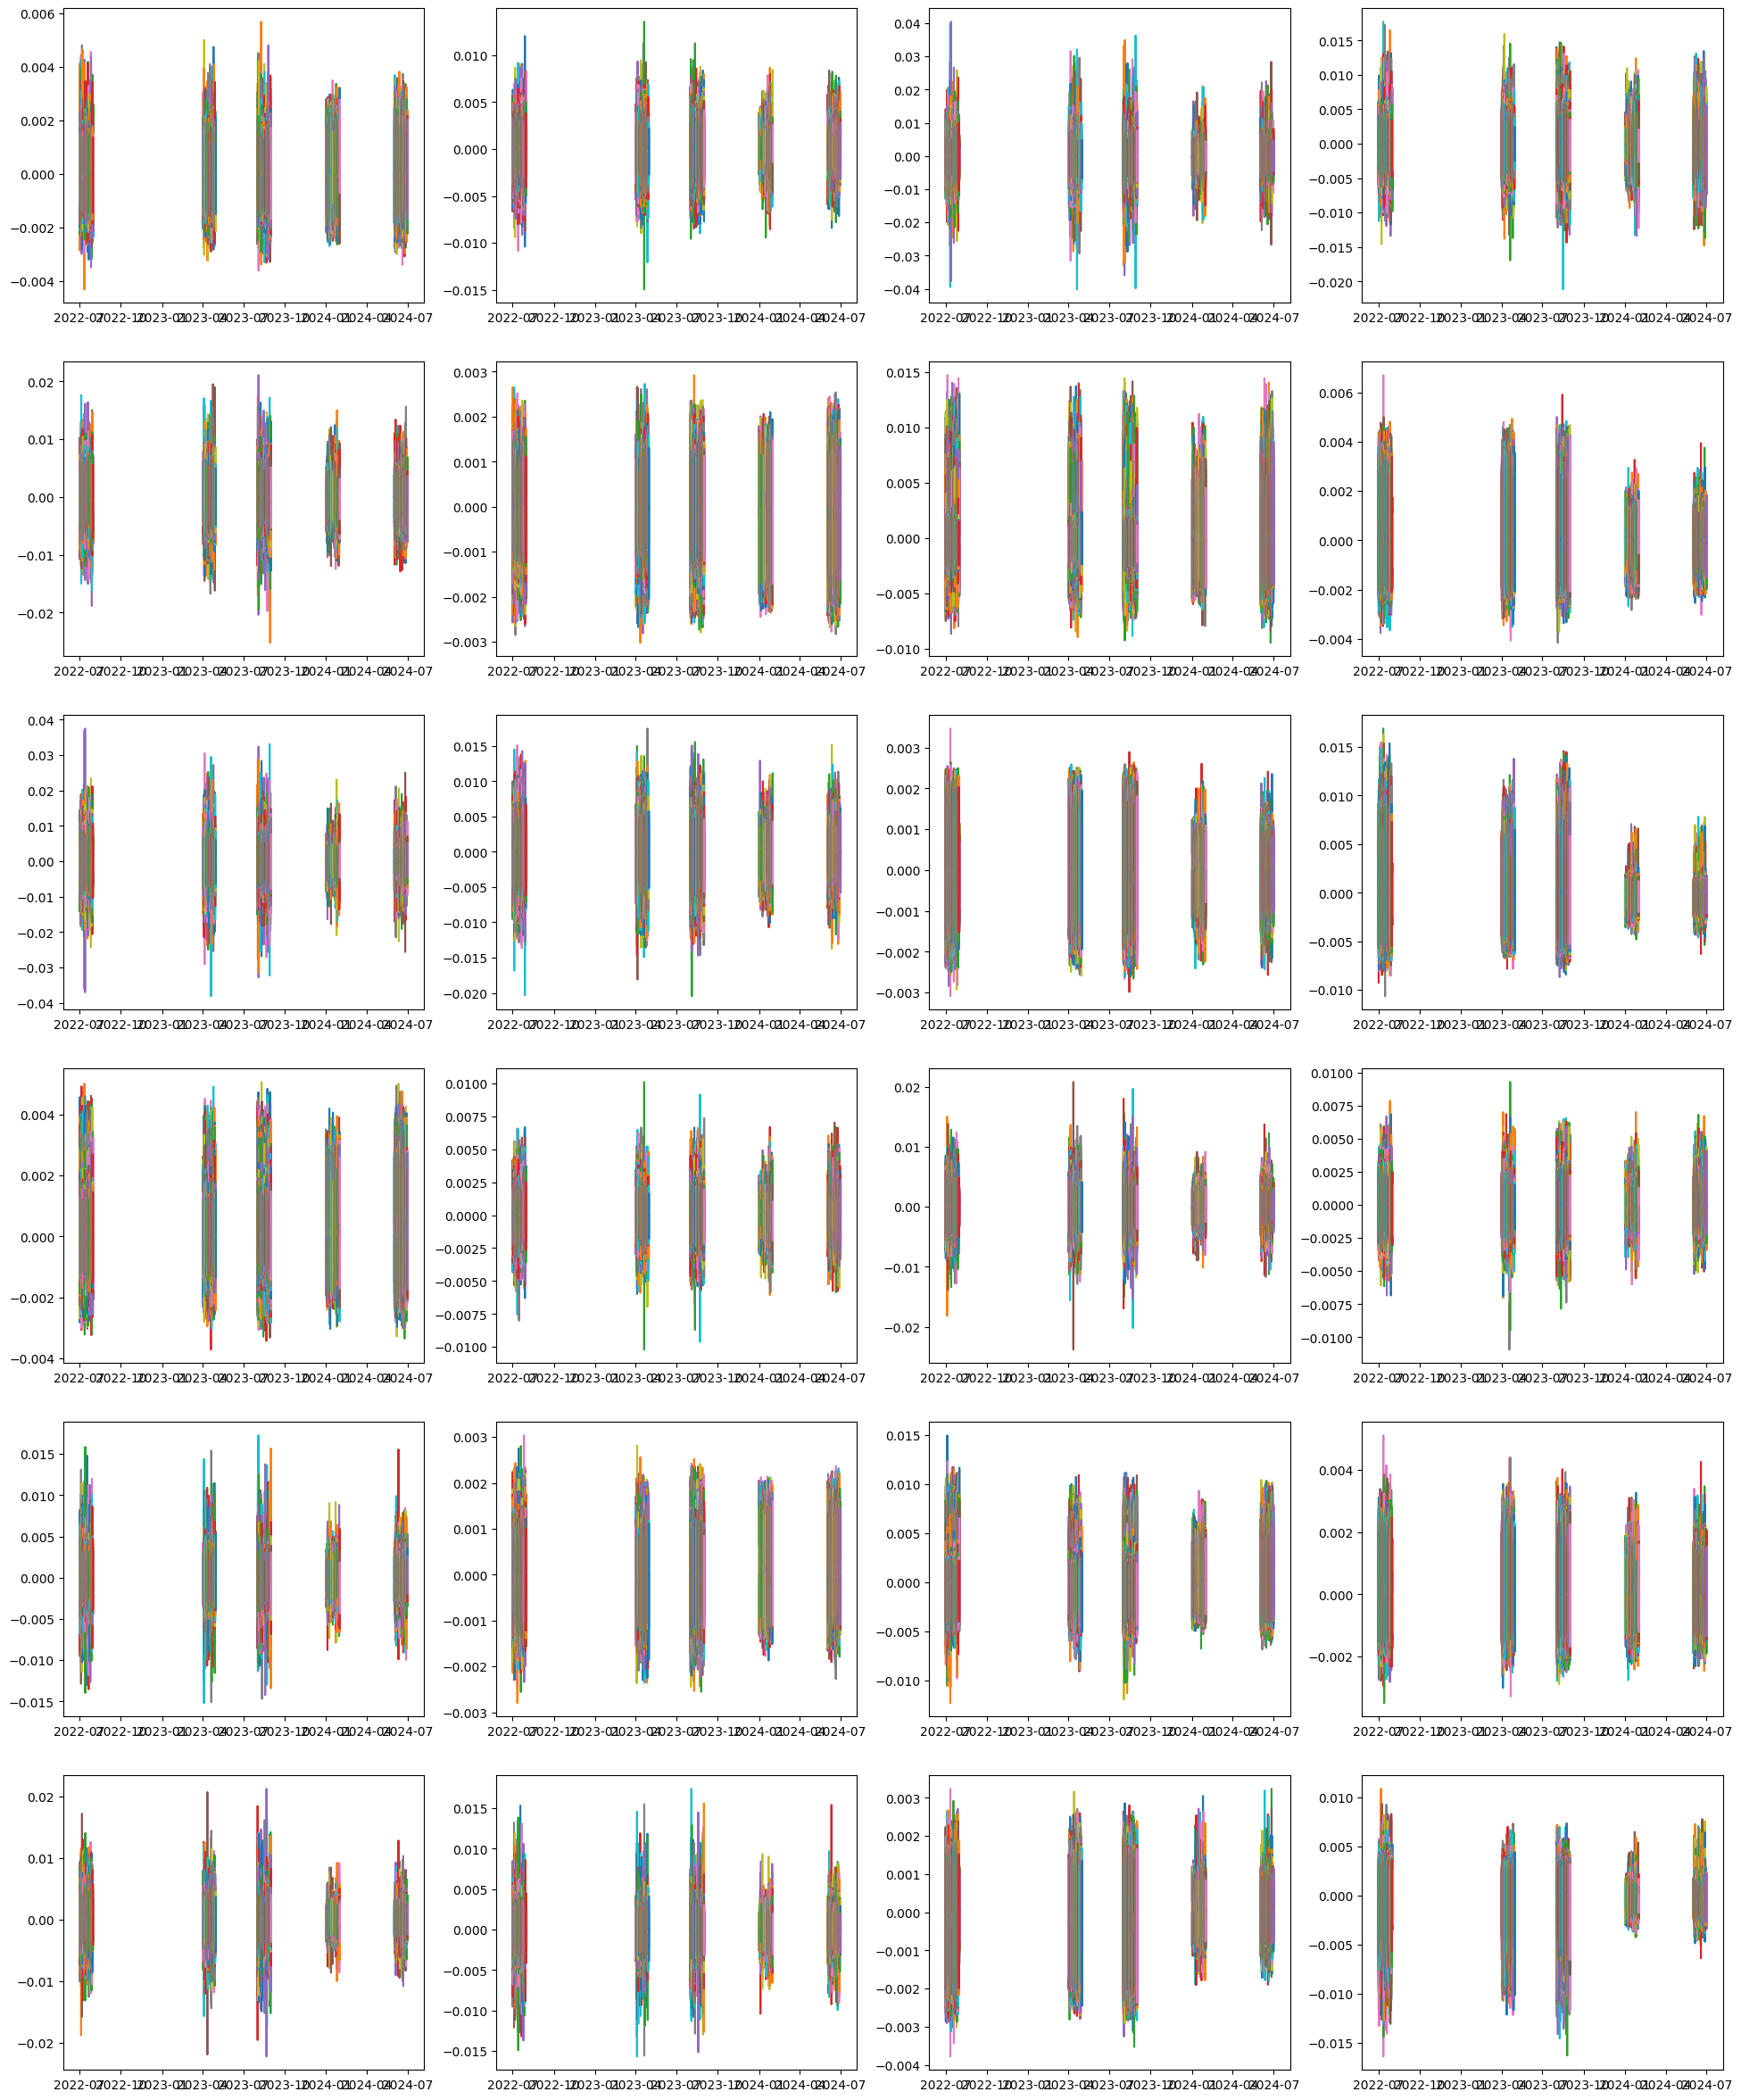

Number of irregular files: 20258


In [6]:
#Jeg tror hver kolonne er en sensor og hver rad er en tid
#Men noen av dem har 22 kolonner istedenfor 24

irregulars = 0

set_times = {}
set_vals = {}

plt.figure(figsize = (24,30))

for folder in folders:

    print(folder)

    npy_files = list(Path(path,folder).glob('*.npy'))

    folder_times,  folder_vals = [], []


    for f in npy_files:
        df = np.load(f)
        start_time = datetime.strptime(f.name.split('__')[2], "%Y-%m-%dT%H-%M-%SZ")
        stop_time = datetime.strptime(f.name.split('__')[3][:-4], "%Y-%m-%dT%H-%M-%SZ")
        times = pd.date_range(start=start_time, end=stop_time, periods = len(df))




        if df.shape[1] != 24:
            irregulars += 1
            continue
        else:
            folder_times.append(times)
            folder_vals.append(df)


        for i in range(24):
            plt.subplot(6,4,i+1)
            plt.plot(times,df[:,i])

    set_times[folder] = folder_times
    set_vals[folder] = folder_vals

plt.show()
print(f"Number of irregular files: {irregulars}")   

In [61]:
import numpy as np
from numpy.lib.stride_tricks import sliding_window_view

def count_point_anomalies(events, window=100, threshold=3):
    # summarize previous events to build baseline
    X = np.array([e.mean(axis=0) for e in events])

    windows = sliding_window_view(X[:-1], window, axis=0)

    means = windows.mean(axis=2)   # (num_eval_events, 24)
    stds  = windows.std(axis=2, ddof=1)

    anomaly_counts = []
    anomaly_rates = []


    for i, event in enumerate(events[window:]):
        z = (event - means[i]) / stds[i]

        # count anomalous time points per feature
        counts = np.sum(np.abs(z) > threshold, axis=0)

        rates = counts / event.shape[0]

        anomaly_rates.append(rates)

        anomaly_counts.append(counts)

    return np.array(anomaly_counts), np.array(anomaly_rates), means, stds

In [64]:
set_counts = {}
set_rates = {}
set_means = {}
set_stds = {}

for f in folders:
    counts, rates, means, stds = count_point_anomalies(set_vals[f])
    set_counts[f] = counts
    set_rates[f] = rates
    set_means[f] = means
    set_stds[f] = stds


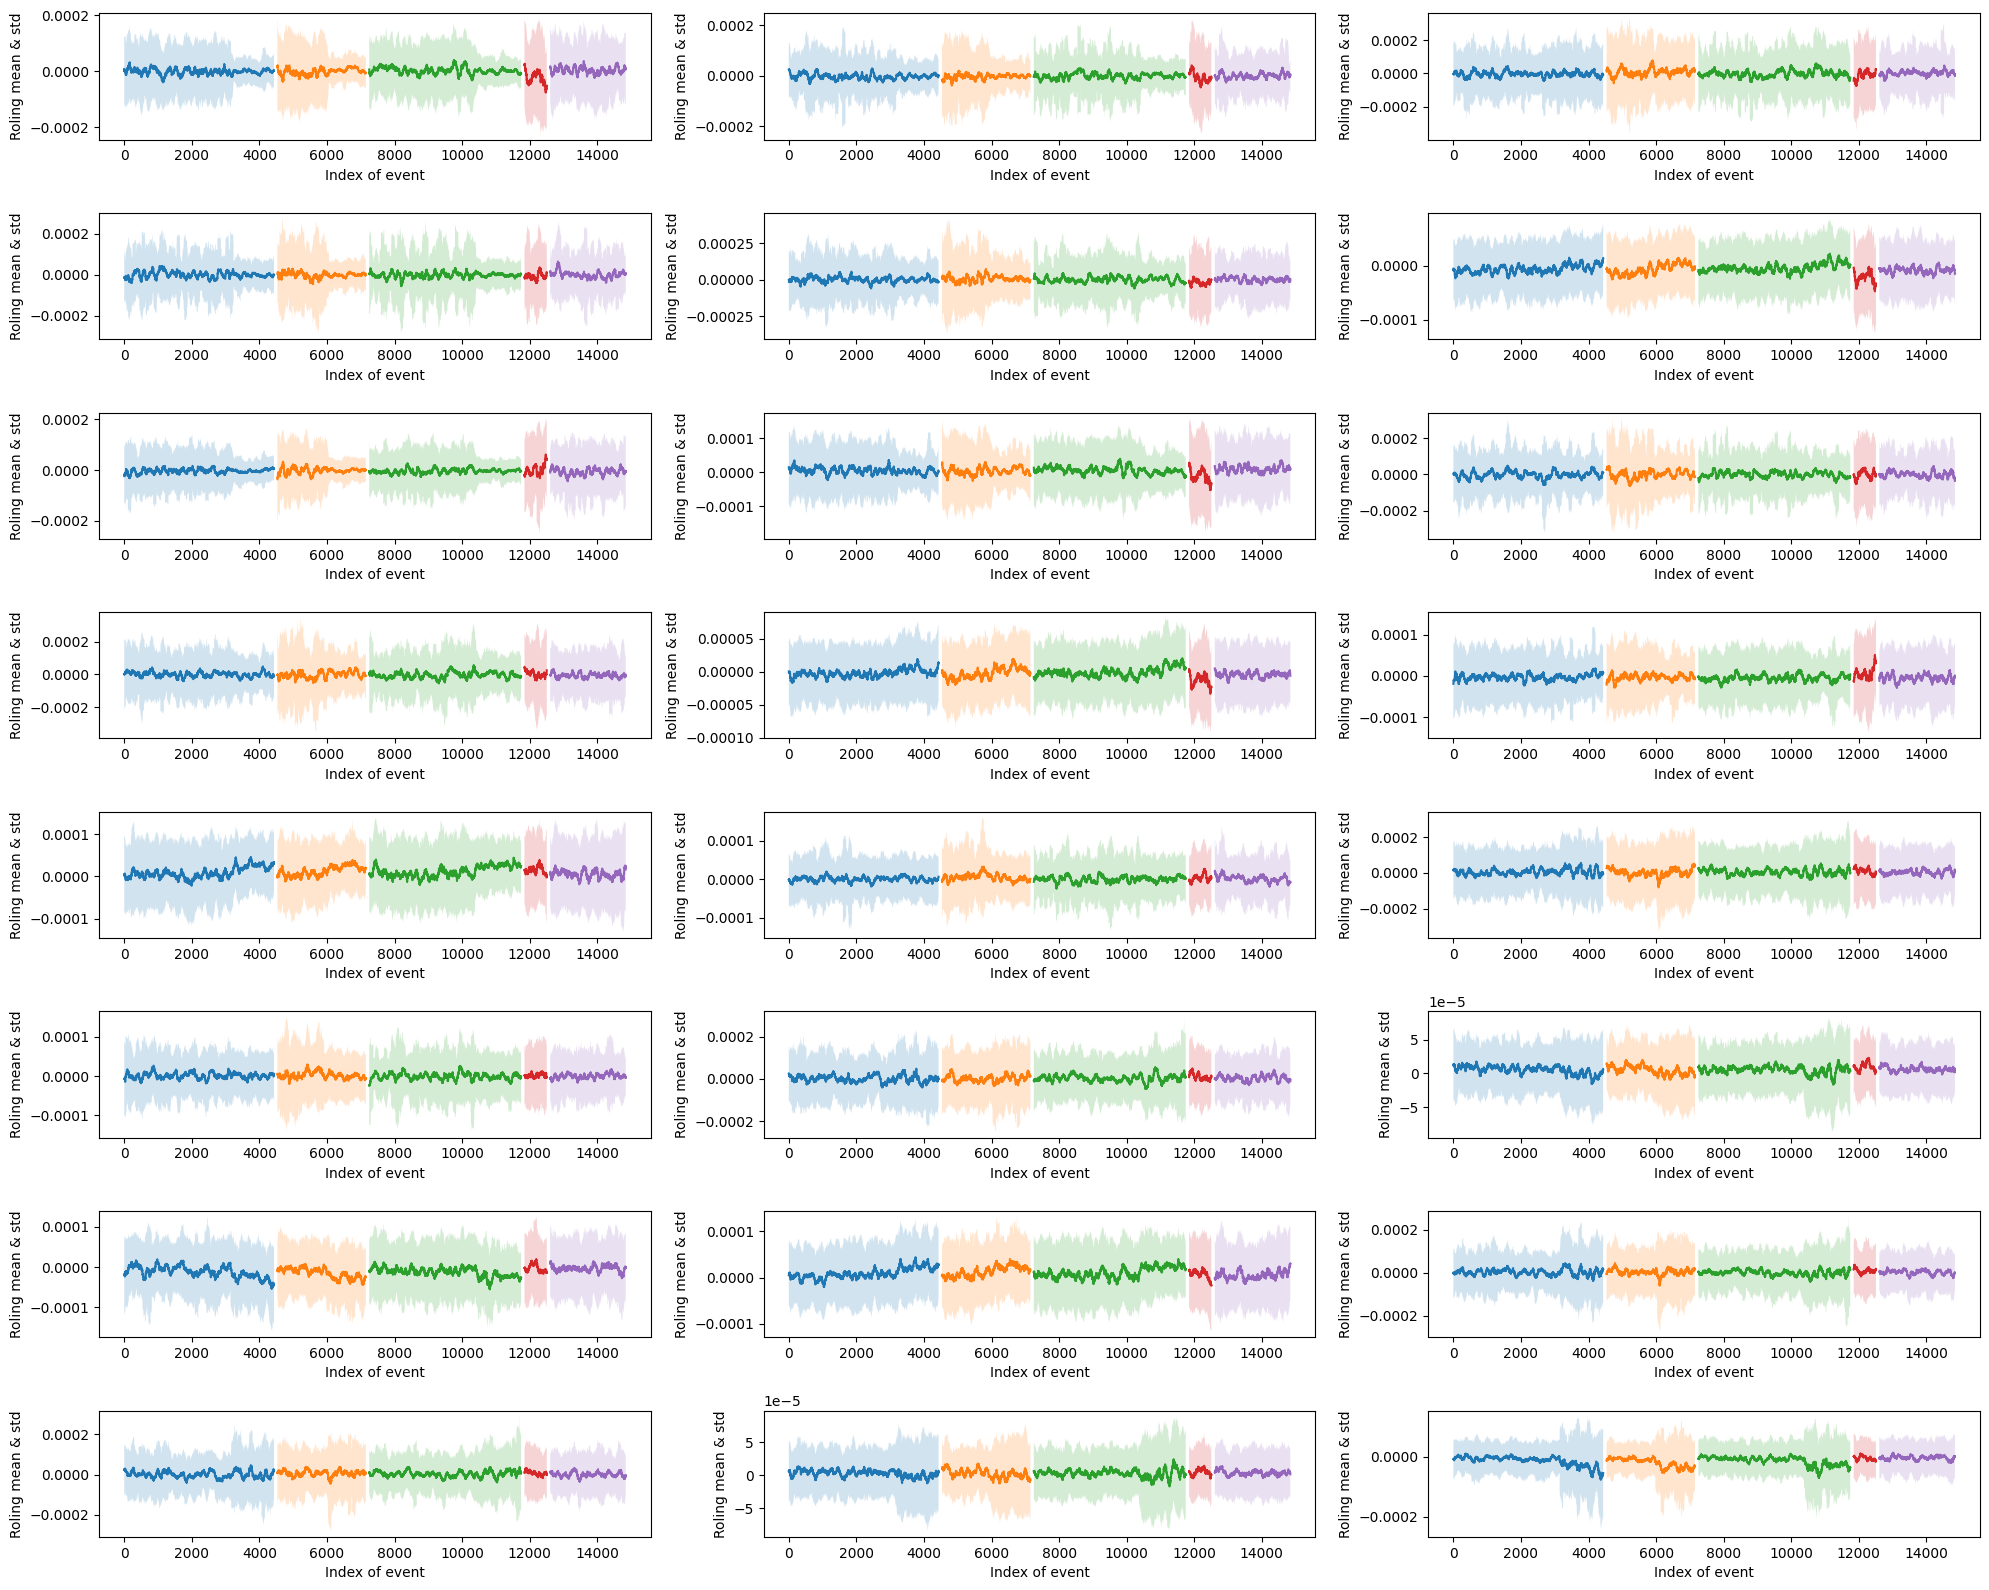

In [67]:
plt.figure(figsize=(20,16))

for i in range(24):

    plt.subplot(8,3,i+1)

    idx = 0  # reset per feature only

    for f in folders:
        current_rate = set_means[f][:, i]
        current_std = set_stds[f][:, i]

        x = np.arange(idx, idx + len(current_rate))

        plt.plot(x, current_rate, label=f)

        plt.fill_between(x, current_rate - current_std, current_rate + current_std, label = f, alpha=0.2)

        idx += len(current_rate) + 100

    plt.ylabel('Roling mean & std')
    plt.xlabel('Index of event')
    #plt.yscale('log')
    #plt.legend()

plt.tight_layout()
plt.show()

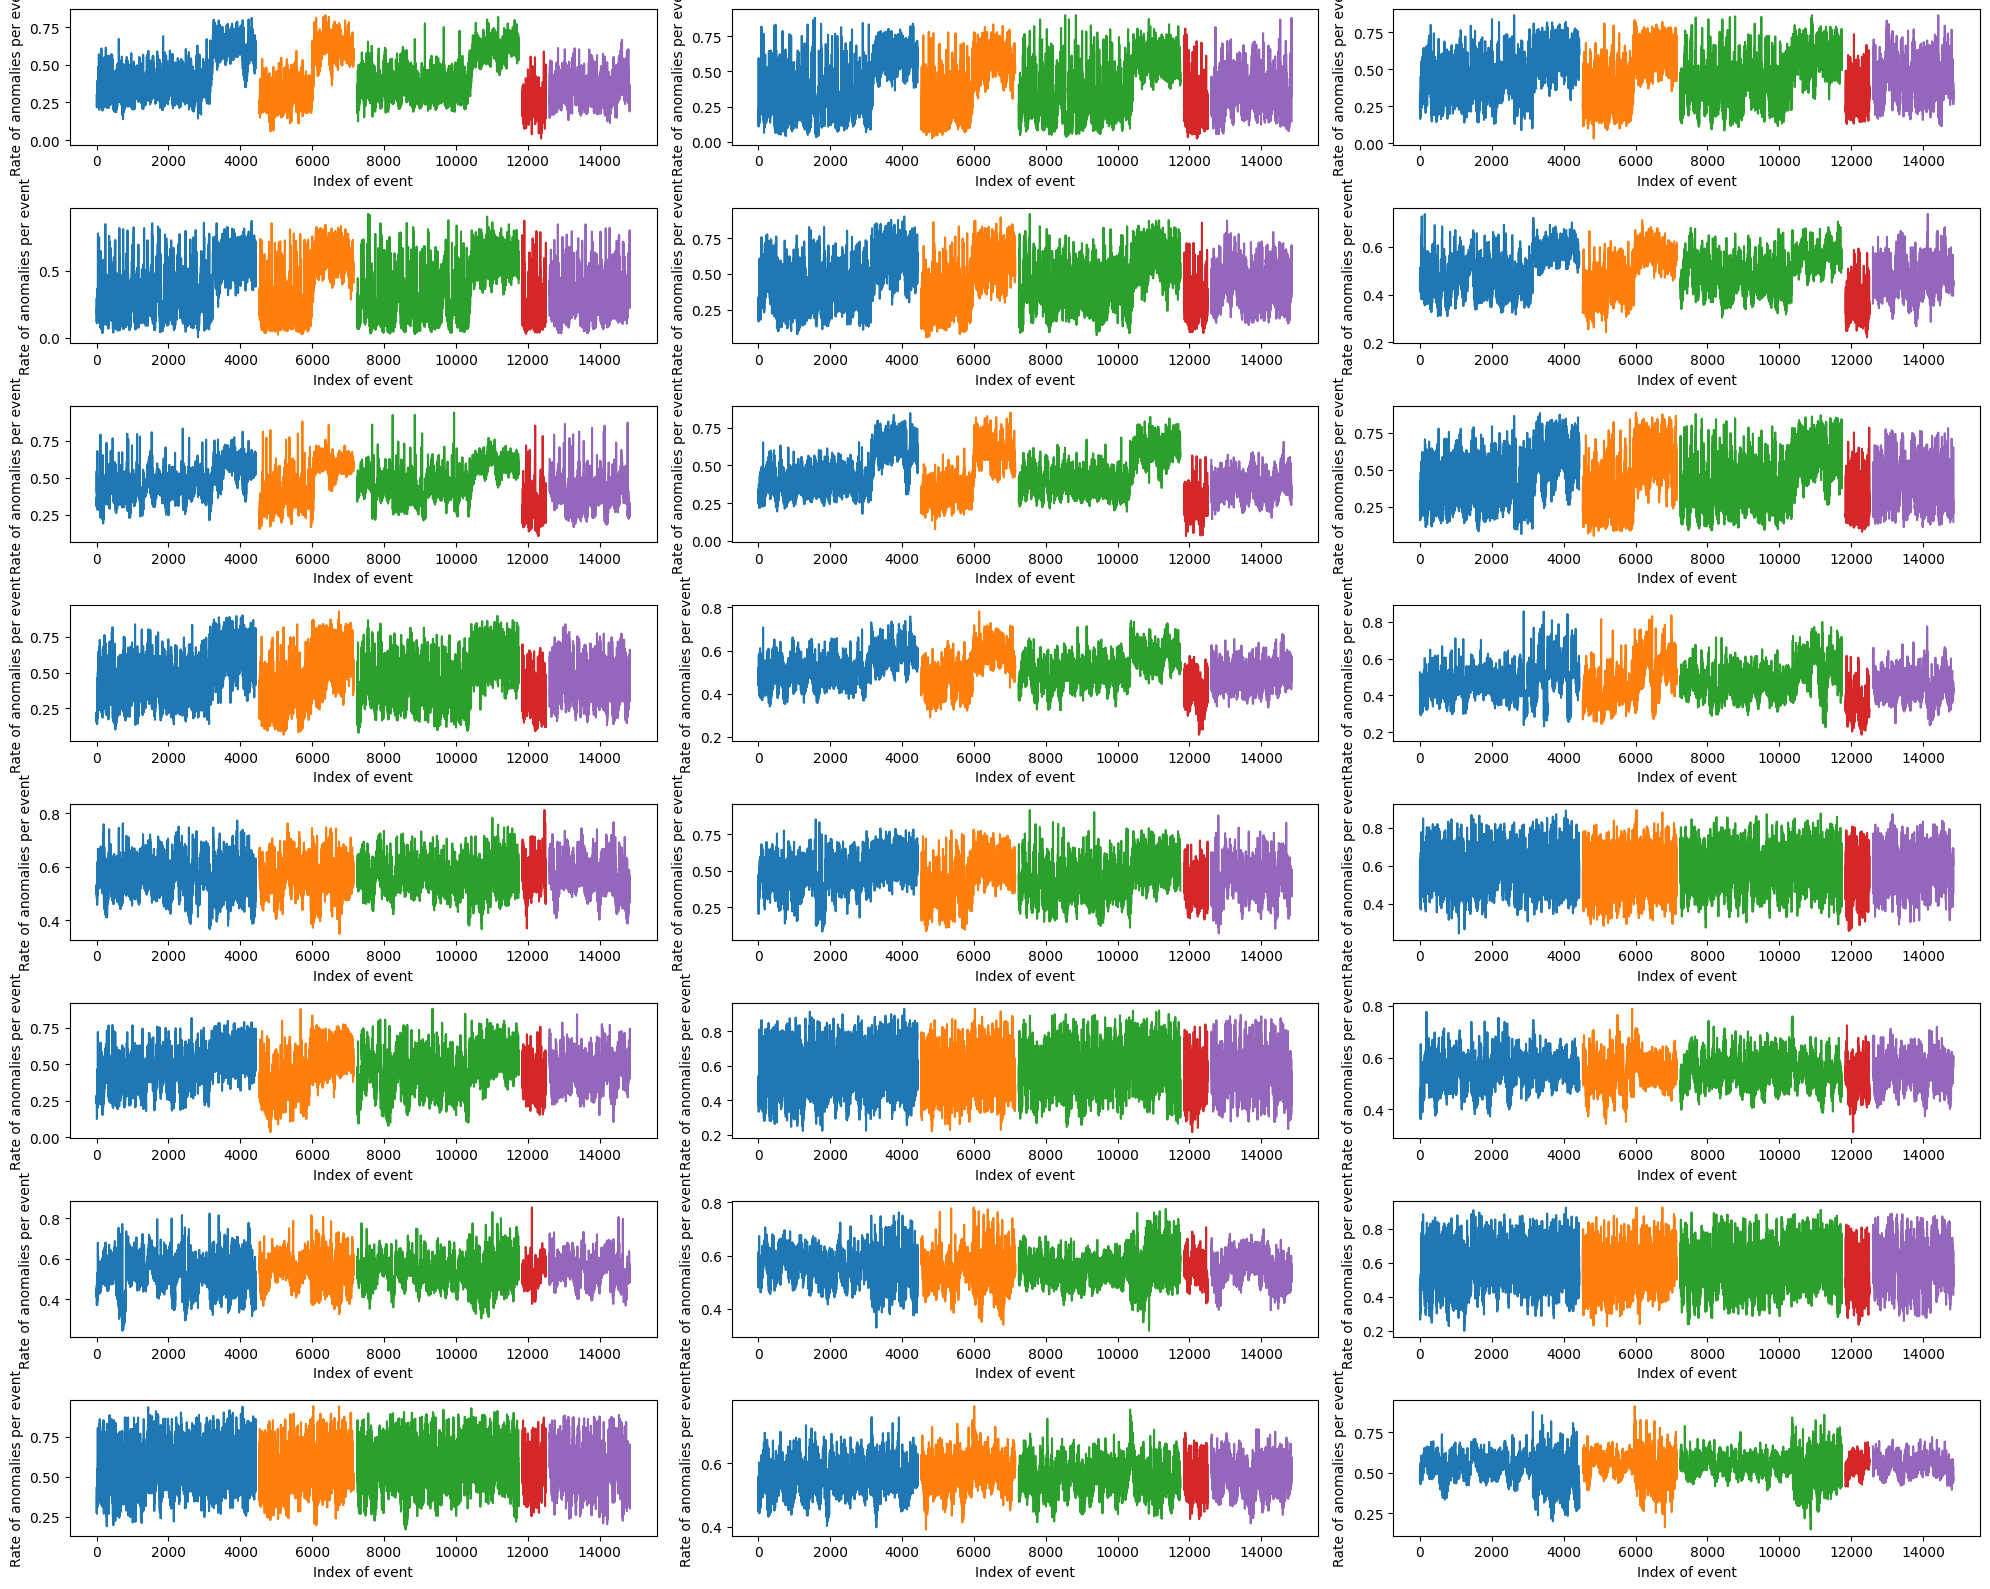

In [68]:
plt.figure(figsize=(20,16))

for i in range(24):

    plt.subplot(8,3,i+1)

    idx = 0  # reset per feature only

    for f in folders:
        current_rate = set_rates[f][:, i]

        x = np.arange(idx, idx + len(current_rate))

        plt.plot(x, current_rate, label=f)

        idx += len(current_rate) + 100

    plt.ylabel('Rate of anomalies per event')
    plt.xlabel('Index of event')
    #plt.yscale('log')
    #plt.legend()

plt.tight_layout()
plt.show()

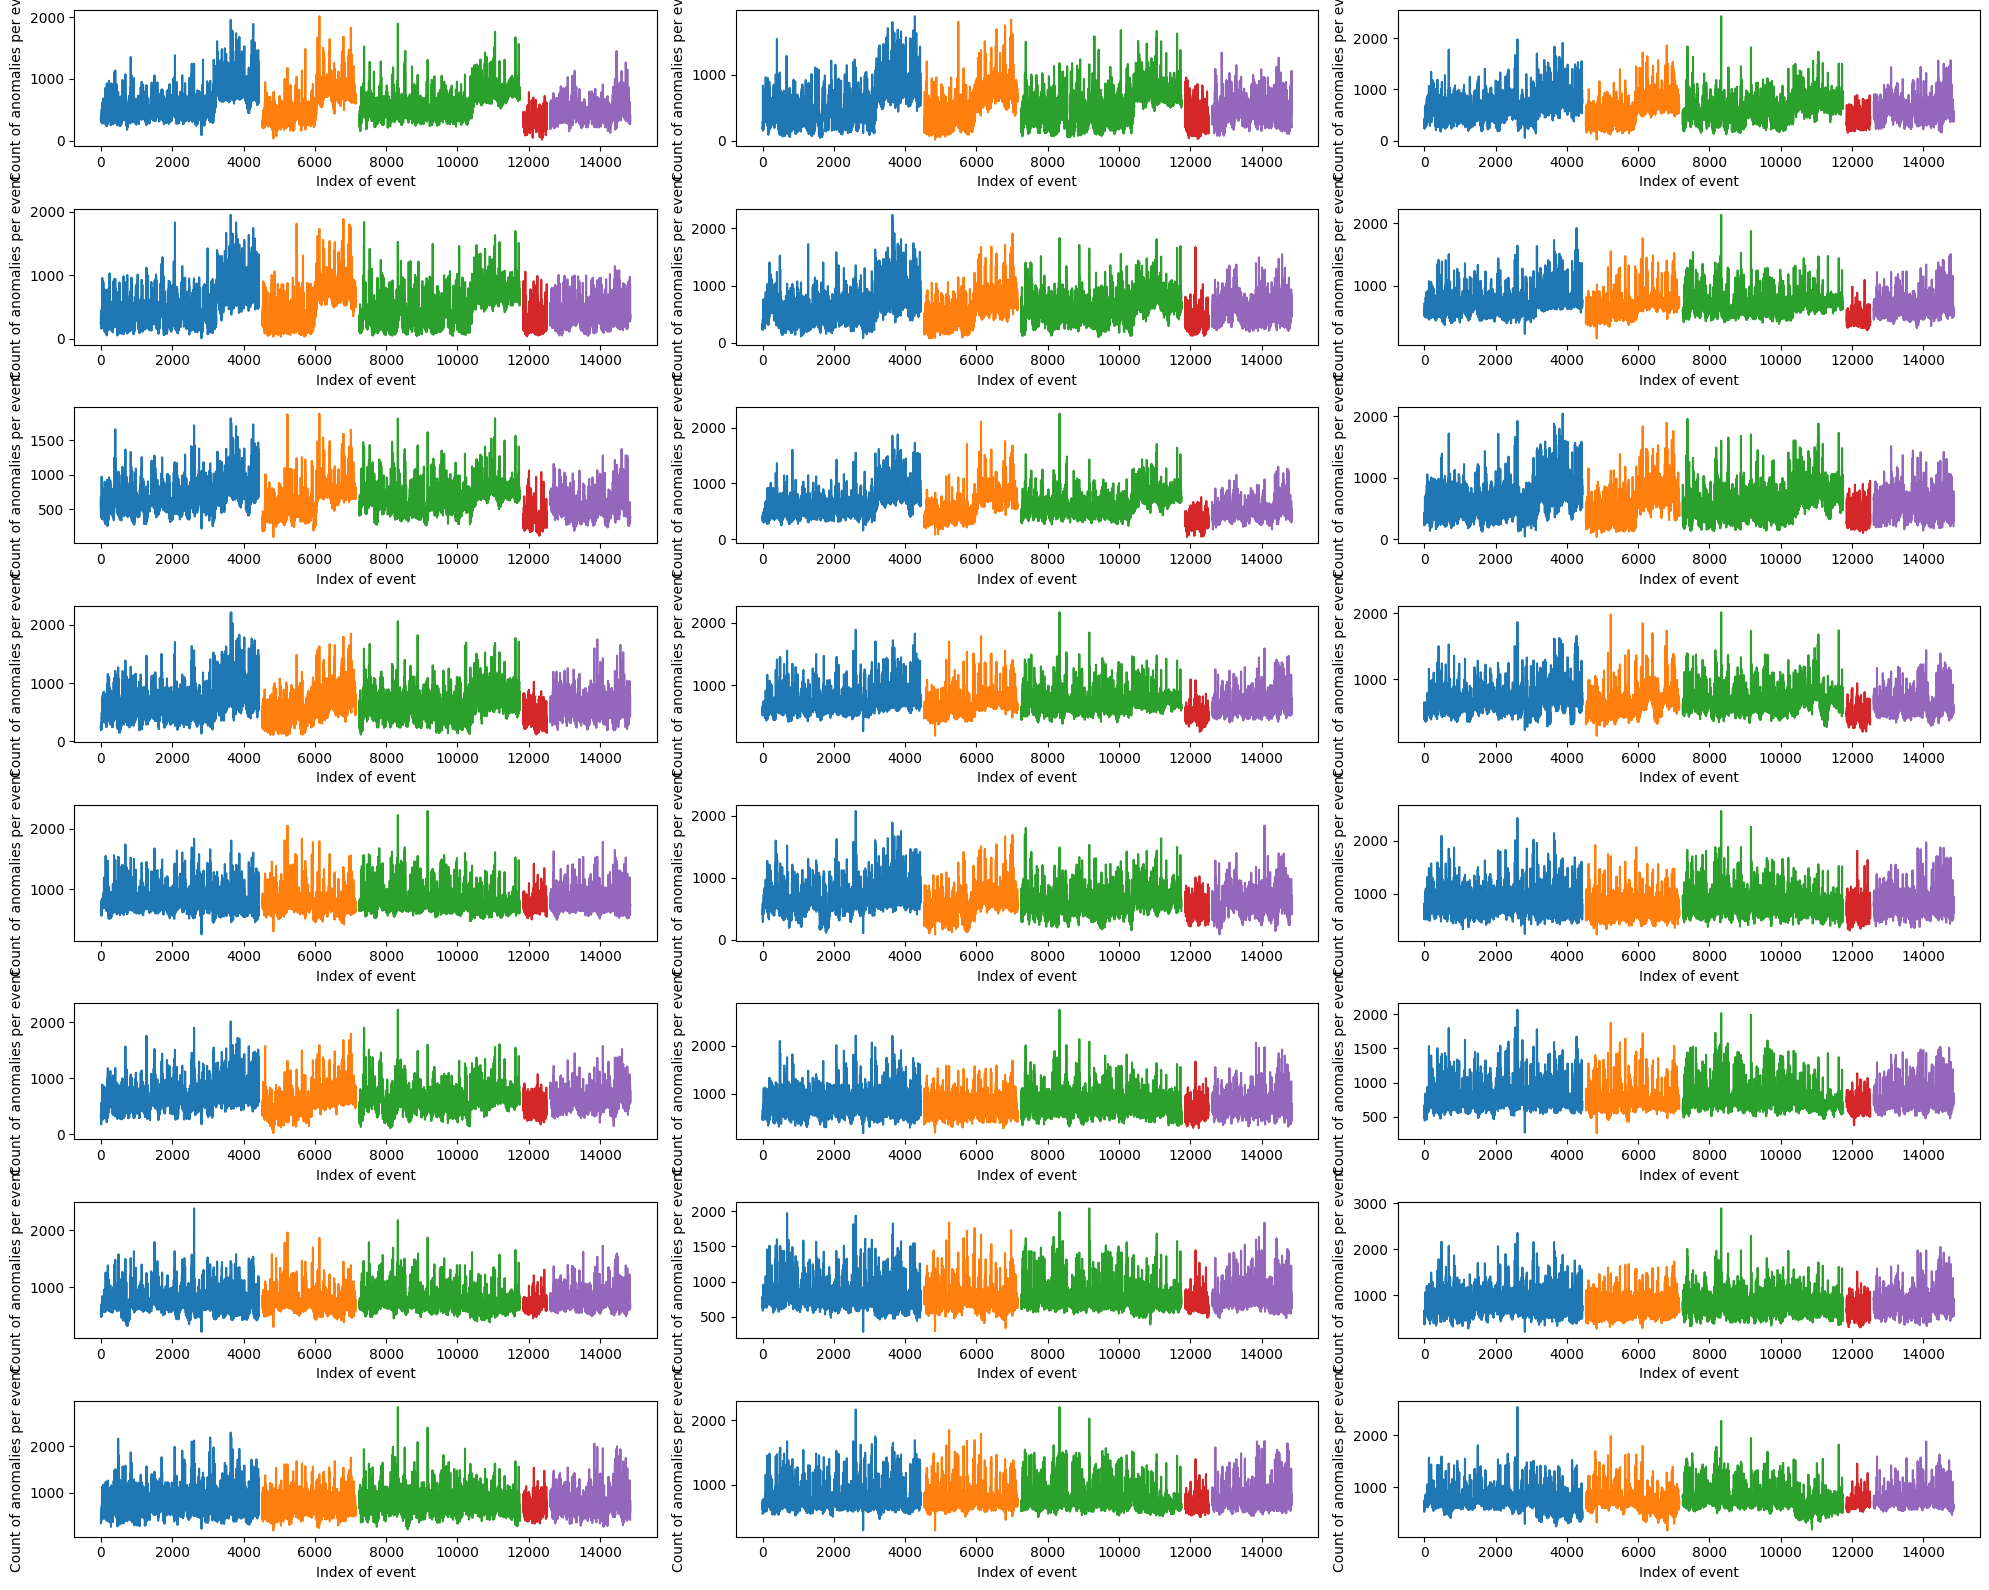

In [69]:
plt.figure(figsize=(20,16))

for i in range(24):

    plt.subplot(8,3,i+1)

    idx = 0  # reset per feature only

    for f in folders:
        current_rate = set_counts[f][:, i]

        x = np.arange(idx, idx + len(current_rate))

        plt.plot(x, current_rate, label=f)

        idx += len(current_rate) + 100

    plt.ylabel('Count of anomalies per event')
    plt.xlabel('Index of event')
    #plt.yscale('log')
    #plt.legend()

plt.tight_layout()
plt.show()